# 

In [1939]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1941]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm import tqdm
from nba import NBAbase, NBAetl, NBAdata, NBAmodels
from betting import funcs
odds = funcs.odds()
import pickle
import shap
#from nba_api.stats.endpoints import LeagueDashPtStats, PlayerIndex, LeagueDashOppPtShot, PlayByPlayV2, PlayByPlay, PlayByPlayV3
etl = NBAetl.etl()
data = NBAdata.data()
import datetime as dt
import requests
import time
import sidetable

--- Runs for Threes

In [1933]:
import pandas as pd
import re
import math


def parse_bet_info(bet_info):
    """Parse bet_info to extract player, over_under, and threes_made"""
    if pd.isna(bet_info):
        return None, None, None

    player = None
    over_under = None
    threes_made = None

    # Pattern 1: "Player Name X+ Made Threes" (e.g., "Anthony Edwards 5+ Made Threes")
    match = re.match(r'^(.+?)\s+(\d+)\+\s+Made Threes', bet_info)
    if match:
        player = match.group(1).strip()
        over_under = f"{match.group(2)}+"
        threes_made = int(match.group(2))
        return player, over_under, threes_made

    # Pattern 2: "Player Name Under X.X Player Name - Alt Threes" (e.g., "Shai Gilgeous-Alexander Under 0.5 Shai...")
    match = re.match(r'^(.+?)\s+Under\s+(\d+\.?\d*)\s+', bet_info, re.IGNORECASE)
    if match:
        player = match.group(1).strip()
        over_under = "under"
        num = float(match.group(2))
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 3: "Under X.X Player Name Total 3-Pointers Made" (e.g., "Under 0.5 Tobias Harris Total 3-Pointers Made")
    match = re.match(r'^Under\s+(\d+\.?\d*)\s+(.+?)\s+Total 3-Pointers Made', bet_info, re.IGNORECASE)
    if match:
        num = float(match.group(1))
        player = match.group(2).strip()
        over_under = "under"
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 4: "Under X.X Player Name Three Pointers Made O/U" (e.g., "Under 1.5 Ayo Dosunmu Three Pointers Made O/U")
    match = re.match(r'^Under\s+(\d+\.?\d*)\s+(.+?)\s+Three Pointers Made', bet_info, re.IGNORECASE)
    if match:
        num = float(match.group(1))
        player = match.group(2).strip()
        over_under = "under"
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 5: "Player Name - Over X.X Threes Made O/U" (e.g., "Donte DiVincenzo - Over 2.5 Threes Made O/U")
    match = re.match(r'^(.+?)\s+-\s+Over\s+(\d+\.?\d*)\s+Threes Made', bet_info, re.IGNORECASE)
    if match:
        player = match.group(1).strip()
        over_under = "over"
        num = float(match.group(2))
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 6: "Player Name - Under X.X Threes Made O/U" (e.g., "Aaron Wiggins - Under 2.5 Threes Made O/U")
    match = re.match(r'^(.+?)\s+-\s+Under\s+(\d+\.?\d*)\s+Threes Made', bet_info, re.IGNORECASE)
    if match:
        player = match.group(1).strip()
        over_under = "under"
        num = float(match.group(2))
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 7: "Player Name: X+ Threes Made" (e.g., "Donte DiVincenzo: 4+ Threes Made")
    match = re.match(r'^(.+?):\s*(\d+)\+\s+Threes Made', bet_info)
    if match:
        player = match.group(1).strip()
        over_under = f"{match.group(2)}+"
        threes_made = int(match.group(2))
        return player, over_under, threes_made

    # Pattern 8: "X+ Player Name Three Pointers Made" (e.g., "2+ Reed Sheppard Three Pointers Made")
    match = re.match(r'^(\d+)\+\s+(.+?)\s+Three Pointers Made', bet_info)
    if match:
        over_under = f"{match.group(1)}+"
        player = match.group(2).strip()
        threes_made = int(match.group(1))
        return player, over_under, threes_made

    # Pattern 9: "Player Name Over X.X Player Name - Made Threes" (e.g., "De'Anthony Melton Over 1.5 De'Anthony Melton - Made Threes")
    match = re.match(r'^(.+?)\s+Over\s+(\d+\.?\d*)\s+', bet_info, re.IGNORECASE)
    if match:
        player = match.group(1).strip()
        over_under = "over"
        num = float(match.group(2))
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 10: "Over X.X Player Name Total 3-Pointers Made"
    match = re.match(r'^Over\s+(\d+\.?\d*)\s+(.+?)\s+Total 3-Pointers Made', bet_info, re.IGNORECASE)
    if match:
        num = float(match.group(1))
        player = match.group(2).strip()
        over_under = "over"
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 11: "Over X.X Player Name Three Pointers Made O/U"
    match = re.match(r'^Over\s+(\d+\.?\d*)\s+(.+?)\s+Three Pointers Made', bet_info, re.IGNORECASE)
    if match:
        num = float(match.group(1))
        player = match.group(2).strip()
        over_under = "over"
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 12: "X+ Player Name Total 3-Pointers Made" (e.g., "5+ Egor Demin Total 3-Pointers Made")
    match = re.match(r'^(\d+)\+\s+(.+?)\s+Total 3-Pointers Made', bet_info)
    if match:
        over_under = f"{match.group(1)}+"
        player = match.group(2).strip()
        threes_made = int(match.group(1))
        return player, over_under, threes_made

    # Pattern 13: "Over X.X Player Name (TEAM): Three-pointers made" (e.g., "Over 1.5 Miles McBride (NYK): Three-pointers made")
    match = re.match(r'^Over\s+(\d+\.?\d*)\s+(.+?)\s+\([A-Z]+\):\s*Three-pointers made', bet_info, re.IGNORECASE)
    if match:
        num = float(match.group(1))
        player = match.group(2).strip()
        over_under = "over"
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 14: "Under X.X Player Name (TEAM): Three-pointers made"
    match = re.match(r'^Under\s+(\d+\.?\d*)\s+(.+?)\s+\([A-Z]+\):\s*Three-pointers made', bet_info, re.IGNORECASE)
    if match:
        num = float(match.group(1))
        player = match.group(2).strip()
        over_under = "under"
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 15: "Player less than X - Three Pointers" (e.g., "Chet Holmgren less than 1 - Three Pointers")
    match = re.match(r'^(.+?)\s+less than\s+(\d+\.?\d*)\s+-\s+Three Pointers', bet_info, re.IGNORECASE)
    if match:
        player = match.group(1).strip()
        over_under = "under"
        num = float(match.group(2))
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 16: "Yes Player to make X+ three-pointers" (e.g., "Yes Julian Champagnie to make 2+ three-pointers")
    match = re.match(r'^Yes\s+(.+?)\s+to make\s+(\d+)\+\s+three-pointers', bet_info, re.IGNORECASE)
    if match:
        player = match.group(1).strip()
        over_under = f"{match.group(2)}+"
        threes_made = int(match.group(2))
        return player, over_under, threes_made

    # Pattern 17: "Under X.X Player Name (TEAM) : Three-pointers made" (with extra space before colon)
    match = re.match(r'^Under\s+(\d+\.?\d*)\s+(.+?)\s+\([A-Z]+\)\s*:\s*Three-pointers made', bet_info, re.IGNORECASE)
    if match:
        num = float(match.group(1))
        player = match.group(2).strip()
        over_under = "under"
        threes_made = math.ceil(num)
        return player, over_under, threes_made

    # Pattern 18: "Over X.X Player Name (TEAM) : Three-pointers made" (with extra space before colon)
    match = re.match(r'^Over\s+(\d+\.?\d*)\s+(.+?)\s+\([A-Z]+\)\s*:\s*Three-pointers made', bet_info, re.IGNORECASE)
    if match:
        num = float(match.group(1))
        player = match.group(2).strip()
        over_under = "over"
        threes_made = math.ceil(num)
        return player, over_under, threes_made
    
    #Pattern 19: There is a parlay so it contains a pipe to delimit the bets

    return player, over_under, threes_made

df = pd.read_csv('../nba/data/pikkit/transactions.csv')

# Filter for ModPlay tags (handle potential whitespace)
modplay_df = df[df['tags'].fillna('').str.contains('ModPlay', case=False, na=False)].copy()
# Apply parsing
parsed = modplay_df['bet_info'].apply(parse_bet_info)
modplay_df['player'] = [p[0] for p in parsed]
modplay_df['over_under'] = [p[1] for p in parsed]
modplay_df['threes_made'] = [p[2] for p in parsed]

# Convert X+ to "over" in over_under column
modplay_df['over_under'] = modplay_df['over_under'].apply(lambda x: 'over' if pd.notna(x) and '+' in str(x) else x)

# Convert threes_made to nullable integer
modplay_df['threes_made'] = modplay_df['threes_made'].astype('Int64')

In [2392]:
def calibrationCheck(startDate):
    td = data.threes_pipe(threes.data)
    td = data.clean_na(td)
    td = td[td.game_date>=(startDate)]
    td = threes.standRobust_scaler(td)
    idInfo = threes.data[threes.data.game_date>=startDate][['name','team','game_id']]
    preds= threes.model.predict(sm.add_constant(td.filter(threes.features),has_constant='add'))
    return idInfo.join(preds),td[['game_date','name','threesMade']]
    
def bookPlays(df,book,min_val=5):
    '''
    Need a dataframe with book values and probability with a line, will get all plays where espn is the best over a minimum amount
    Inputs: DataFrame, book -- DraftKings,FanDuel,theScore Bet,BetMGM
    '''
    #set first book to whatever book should be default for tie-breakers
    books = ['FanDuel','DraftKings','theScore Bet','BetMGM',"Fanatics"]
    max_col = df.filter(books).idxmax(axis=1)
    df = df[(max_col==book) & (df['{}Amount'.format(book)]>min_val)]
    final = df.filter(['name','threesMade','over_under','team','value','prob']+books+['{}Amount'.format(book)])
    print('proportion of plays:')
    print(max_col.to_frame(name='Book').stb.freq(['Book']).to_string(index=False))
    
    return final.sort_values(by='{}Amount'.format(book),ascending=False)
    

# def playerSearch()

# def leagueStats()

In [3955]:
etl.update_shots_allowed(['2026-04-03'])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.41it/s]


In [3513]:
n=10
end_date = (dt.datetime.today() + pd.to_timedelta(-2,unit='day')).strftime(format='%Y-%m-%d')
start_date = (dt.datetime.today() + pd.to_timedelta(-n,unit='day')).strftime(format='%Y-%m-%d')
df  = pd.read_sql('''SELECT game_id,team_id,game_date,wide_fg2a,wide_fg3m,open_fg3m,open_fg3a
                  FROM shotsAllowed 
                  WHERE game_date BETWEEN '{}' AND '{}' '''.format(start_date,end_date),
                  etl.conn)

In [3953]:
df = etl.get_open_shot_allowed(["2026-04-03"])


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:18<00:00, 18.10s/it]


In [3991]:
#get yesterday's data and load
yst = (dt.datetime.today() + pd.to_timedelta(-1,unit='day')).strftime(format='%Y-%m-%d')
gids = etl.get_games(yst,yst)
print('Updating for {}'.format(yst))
etl.update_player_log([yst])
time.sleep(np.random.randint(5,15))
try:
    etl.update_shots_allowed([yst])
except:
    print('shots not updated yet')
time.sleep(np.random.randint(5,15)) 
etl.update_teamLog(gids.GAME_ID.unique())

#save off odds

Updating for 2026-04-09
started player logs at 20:50
getting first buckets : at 20:50


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:15<00:00,  2.56s/it]


	completed at 20:50
started rebounds at 20:50
ended rebounds at 20:50
starting advanced box at 20:50


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:22<00:00, 13.69s/it]


completed adv box at 20:52
start player shots at 20:52


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:28<00:00, 28.66s/it]


completed player shots at 20:52


  0%|                                                                                                                                                                                      | 0/6 [00:30<?, ?it/s]


ReadTimeout: HTTPSConnectionPool(host='cdn.nba.com', port=443): Read timed out. (read timeout=30)

In [3992]:

data.refresh_opp_data()

Refreshing opp_data...


In [4023]:
pd.read_sql('select * from predictions',etl.conn).columns

Index(['player_id', 'date', 'over_under', 'number', 'model_prob', 'FanDuels',
       'DraftKings', 'theScore_Bet', 'ev_fanduel', 'ev_draftkings',
       'ev_espnbet', 'bet_book', 'final_line', 'bet_amount', 'result'],
      dtype='object')

In [3993]:
threes = NBAmodels.models('threes')

td = data.threes_pipe(threes.data)

td = data.clean_na(td)
td = td[td.game_date==(dt.datetime.today()).strftime('%Y-%m-%d')]
td = threes.standRobust_scaler(td)
idInfo = threes.data[threes.data.game_date==dt.datetime.today().strftime('%Y-%m-%d')][['name','team','game_id','player_id']]
idInfo.name = np.where(idInfo.name.str.contains('\.'),idInfo.name.str.replace('.',''),idInfo.name)
idInfo.name = np.where(idInfo.name.str.contains('ë'),idInfo.name.str.replace('ë','e'),idInfo.name)
idInfo.name = np.where(idInfo.name =='Derrick Jones Jr','Derrick Jones',idInfo.name)
idInfo.name = np.where(idInfo.name =='KyShawn George','Kyshawn George',idInfo.name)
idInfo.name = np.where(idInfo.name =='Isaiah Stewart','Isaiah Stewart II',idInfo.name)
idInfo.name = np.where(idInfo.name== 'Ronald Holland II','Ron Holland',idInfo.name)
preds= threes.model.predict(sm.add_constant(td.filter(threes.features),has_constant='add'))
predId = idInfo.join(preds)

In [3994]:

overs = odds.oddsTable(preds,idInfo,'threesMade')
#%2cespnbet
url = 'https://api.the-odds-api.com/v4/sports/basketball_nba/events/{}/odds?apiKey={}&regions=us&markets=player_threes,player_threes_alternate&dateFormat=iso&oddsFormat=american&bookmakers=draftkings%2Cfanduel%2cespnbet%2cfanatics'
df = pd.DataFrame()
events,akey = odds.oddsData(odds.nbaEvents,usePaid=True)
for event in events:
    r = requests.get(url.format(event,akey))
    game = r.json()
    for key in game.get('bookmakers'):
        bk = key.get('title')
        for mrkt in key.get('markets'):
            temp = pd.DataFrame(mrkt.get('outcomes'))
            temp.columns = ['over_under','name','price','threesMade']
            temp['book'] = bk
            df = pd.concat([temp,df])   
odf = df.pivot_table(index=['name','threesMade','over_under'],columns=['book']).reset_index()
odf.columns = [col[1] if col[1]!= '' else col[0] for col in odf.columns]
#Name changes
odf.name = np.where(odf.name=='Herb Jones','Herbert Jones',odf.name)
odf.name = np.where(odf.name =='Alex Sarr','Alexandre Sarr',odf.name)
odf.name = np.where(odf.name =='Tristan da Silva','Tristan Da Silva',odf.name)
odf.name = np.where(odf.name.str.contains('\.'),odf.name.str.replace('.',''),odf.name)
odf.to_csv('../nba/data/csv/{}odds.csv'.format(dt.datetime.today().strftime('%Y-%m-%d')),index=False)
#over.name = np.where(over.name.str.contains('\.'),over.name.str.replace('.',''),over.name)

Free is out
{'Date': 'Sat, 11 Apr 2026 00:54:25 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Content-Length': '909', 'Connection': 'keep-alive', 'X-Requests-Used': '118', 'X-Requests-Remaining': '19882', 'X-Requests-Last': '0', 'vary': 'Accept-Encoding', 'content-encoding': 'gzip', 'Apigw-Requestid': 'boVGWgx7IAMEahg='}


In [4032]:
overs

,name,team,threesMade,value,over_under
420,Chris Paul,LAC,0.5,156,Over
421,Tyus Jones,DAL,0.5,216,Over
422,D'Angelo Russell,WAS,0.5,-105,Over
423,Karl-Anthony Towns,NYK,0.5,-125,Over
424,Kelly Oubre Jr,PHI,0.5,-280,Over
...,...,...,...,...,...
4195,Nikola Jokic,DEN,9.5,-9900,Under
4196,Kristaps Porzingis,GSW,9.5,-9900,Under
4197,Joe Ingles,MIN,9.5,-9900,Under
4198,TJ McConnell,IND,9.5,-9900,Under


In [4077]:
pd.read_sql('select * from predictions',etl.conn).columns

Index(['player_id', 'date', 'over_under', 'number', 'model_prob', 'FanDuels',
       'DraftKings', 'theScore_Bet', 'ev_fanduel', 'ev_draftkings',
       'ev_espnbet', 'bet_book', 'final_line', 'bet_amount', 'result', 'user'],
      dtype='object')

In [4073]:
#overs, idInfo, model = run_model(model_name)
#odf = odds.fetch_odds('threes')
df = odds.bet_table(overs, odf, odds.market_vars.get('threes').get('col_name'))

In [4078]:
pd.read_csv('../nba/data/csv/2026-03-23odds.csv')

,name,threesMade,over_under,DraftKings,FanDuel,Fanatics,theScore Bet
0,Aaron Nesmith,0.5,Over,-516.0,-650.0,NaN,-1000.0
1,Aaron Nesmith,0.5,Under,NaN,NaN,NaN,475.0
2,Aaron Nesmith,1.5,Over,-114.0,-138.0,NaN,-127.5
3,Aaron Nesmith,1.5,Under,-115.0,108.0,NaN,-105.0
4,Aaron Nesmith,2.5,Over,253.0,220.0,NaN,215.0
...,...,...,...,...,...,...,...
871,Ziaire Williams,2.5,Over,271.0,265.0,NaN,250.0
872,Ziaire Williams,2.5,Under,NaN,NaN,NaN,-375.0
873,Ziaire Williams,3.5,Over,710.0,700.0,NaN,700.0
874,Ziaire Williams,4.5,Over,1660.0,1700.0,NaN,1400.0


In [4075]:
df[['player_id','over_under','threesMade','prob','bet_book','final_line','amount','user'a

,name,team,player_id,over_under,threesMade,value,DraftKings,FanDuel,Fanatics,theScore Bet,prob,DraftKingsEV,DraftKingsAmount,FanDuelEV,FanDuelAmount,espnEV,espnAmount
0,Chris Paul,LAC,101108,Over,0.5,156,NaN,NaN,NaN,NaN,0.3906,nan%,NaN,nan%,NaN,nan%,NaN
1,Tyus Jones,DAL,1626145,Over,0.5,216,NaN,NaN,NaN,NaN,0.3165,nan%,NaN,nan%,NaN,nan%,NaN
2,D'Angelo Russell,WAS,1626156,Over,0.5,-105,NaN,NaN,NaN,NaN,0.5122,nan%,NaN,nan%,NaN,nan%,NaN
3,Karl-Anthony Towns,NYK,1626157,Over,0.5,-125,NaN,NaN,NaN,NaN,0.5556,nan%,NaN,nan%,NaN,nan%,NaN
4,Kelly Oubre Jr,PHI,1626162,Over,0.5,-280,120.0,116.0,NaN,NaN,0.7368,62.10%,64.68,59.15%,63.74,nan%,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7975,Nikola Jokic,DEN,203999,Under,9.5,-9900,NaN,NaN,NaN,NaN,0.9900,nan%,NaN,nan%,NaN,nan%,NaN
7976,Kristaps Porzingis,GSW,204001,Under,9.5,-9900,NaN,NaN,NaN,NaN,0.9900,nan%,NaN,nan%,NaN,nan%,NaN
7977,Joe Ingles,MIN,204060,Under,9.5,-9900,NaN,NaN,NaN,NaN,0.9900,nan%,NaN,nan%,NaN,nan%,NaN
7978,TJ McConnell,IND,204456,Under,9.5,-9900,NaN,NaN,NaN,NaN,0.9900,nan%,NaN,nan%,NaN,nan%,NaN


In [4044]:
idInfo.join(odds.accumulateOdds(preds,preds.columns)).

,name,team,game_id,player_id,0,1,2,3,4,5,6,7,8,9
163423,Chris Paul,LAC,0022501183,101108,-155,-604,-2211,-7208,-9900,-9900,-9900,-9900,-9900,-9900
163424,Tyus Jones,DAL,0022501180,1626145,-215,-741,-2544,-7545,-9900,-9900,-9900,-9900,-9900,-9900
163425,D'Angelo Russell,WAS,0022501172,1626156,106,-304,-877,-2178,-6446,-9900,-9900,-9900,-9900,-9900
163426,Karl-Anthony Towns,NYK,0022501176,1626157,126,-255,-698,-1675,-4559,-9900,-9900,-9900,-9900,-9900
163427,Kelly Oubre Jr,PHI,0022501175,1626162,281,-152,-502,-1456,-3927,-9900,-9900,-9900,-9900,-9900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163838,Nikola Jokic,DEN,0022501182,203999,323,-109,-286,-669,-1636,-4155,-9900,-9900,-9900,-9900
163839,Kristaps Porzingis,GSW,0022501184,204001,228,-121,-318,-724,-1948,-4811,-9900,-9900,-9900,-9900
163840,Joe Ingles,MIN,0022501178,204060,-197,-823,-2899,-9665,-9900,-9900,-9900,-9900,-9900,-9900
163841,TJ McConnell,IND,0022501175,204456,-290,-1073,-4111,-9900,-9900,-9900,-9900,-9900,-9900,-9900


In [4060]:

overs = odds.oddsTable(preds,idInfo,'threesMade')

In [4063]:
overs.merge(odf,how="left",on=["name","threesMade","over_under"])

,name,team,player_id,over_under,threesMade,value,DraftKings,FanDuel,Fanatics,theScore Bet
0,Chris Paul,LAC,101108,Over,0.5,156,NaN,NaN,NaN,NaN
1,Tyus Jones,DAL,1626145,Over,0.5,216,NaN,NaN,NaN,NaN
2,D'Angelo Russell,WAS,1626156,Over,0.5,-105,NaN,NaN,NaN,NaN
3,Karl-Anthony Towns,NYK,1626157,Over,0.5,-125,NaN,NaN,NaN,NaN
4,Kelly Oubre Jr,PHI,1626162,Over,0.5,-280,120.0,116.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7975,Nikola Jokic,DEN,203999,Under,9.5,-9900,NaN,NaN,NaN,NaN
7976,Kristaps Porzingis,GSW,204001,Under,9.5,-9900,NaN,NaN,NaN,NaN
7977,Joe Ingles,MIN,204060,Under,9.5,-9900,NaN,NaN,NaN,NaN
7978,TJ McConnell,IND,204456,Under,9.5,-9900,NaN,NaN,NaN,NaN


In [4082]:
odds.kellyCrit(307,410)

EV: 25.31%
Straight Wager 7.72
Parlay 5.79
Payout: $31.63


0.06172469587103732

In [4056]:
odds.bet_table(overs,odf,"threesMade",)

,name,threesMade,over_under,DraftKings,FanDuel,Fanatics,theScore Bet,team,player_id,value,prob,DraftKingsEV,DraftKingsAmount,FanDuelEV,FanDuelAmount,espnEV,espnAmount
0,AJ Green,3.5,Over,-800.0,-1200.0,NaN,NaN,MIL,1631260,266.0,0.2732,-69.27%,-692.65,-70.40%,-1056.05,nan%,NaN
1,AJ Green,4.5,Over,-175.0,-200.0,NaN,-400.0,MIL,1631260,658.0,0.1319,-79.27%,-173.41,-80.22%,-200.54,-83.51%,-417.56
2,AJ Green,5.5,Over,170.0,142.0,NaN,100.0,MIL,1631260,1448.0,0.0646,-82.56%,-60.70,-84.37%,-74.27,-87.08%,-108.85
3,AJ Green,6.5,Over,425.0,360.0,NaN,250.0,MIL,1631260,3096.0,0.0313,-83.57%,-24.58,-85.60%,-29.72,-89.05%,-44.52
4,AJ Green,7.5,Over,1000.0,800.0,NaN,NaN,MIL,1631260,5688.0,0.0173,-80.97%,-10.12,-84.43%,-13.19,nan%,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,Victor Wembanyama,2.5,Over,-350.0,-200.0,NaN,NaN,SAS,1641705,300.0,0.2500,-67.86%,-296.88,-62.50%,-156.25,nan%,NaN
584,Victor Wembanyama,3.5,Over,135.0,205.0,NaN,170.0,SAS,1641705,730.0,0.1205,-71.68%,-66.37,-63.25%,-38.57,-67.47%,-49.61
585,Victor Wembanyama,4.5,Over,400.0,600.0,NaN,500.0,SAS,1641705,1775.0,0.0533,-73.35%,-22.92,-62.69%,-13.06,-68.02%,-17.00
586,Victor Wembanyama,5.5,Over,1100.0,1280.0,NaN,1200.0,SAS,1641705,4948.0,0.0198,-76.24%,-8.66,-72.68%,-7.10,-74.26%,-7.74


In [4050]:
odds.bet_table(overs,odf,'threesMade')

KeyError: 'player_id'

In [3995]:
td.filter(threes.features).describe().T

,count,mean,std,min,25%,50%,75%,max
cornerRatio,420.0,-0.047587,0.639467,-0.761489,-0.514611,-0.215963,0.375155,1.269843
abv_interaction,420.0,0.074182,1.118776,-1.232414,-0.820741,-0.124645,0.675174,4.332098
crn_interaction,420.0,0.031417,1.303025,-1.329095,-0.991951,-0.294657,0.820216,5.967255
mvAvgThrees,420.0,-0.093600,0.932750,-1.224947,-0.912299,-0.287003,0.494617,3.152124
daysBetweenGames,420.0,3.354762,3.685792,0.000000,1.000000,1.000000,6.000000,10.000000
wide_interaction,420.0,0.189024,0.873747,-1.607189,-0.195846,0.203541,0.606308,5.278000
home,420.0,0.511905,0.500454,0.000000,0.000000,1.000000,1.000000,1.000000
crn_fgaMv,420.0,-0.035505,1.200224,-1.379654,-1.026662,-0.328030,0.768424,3.830321
abv_fgaMv,420.0,0.033053,1.089574,-1.248198,-0.836173,-0.165571,0.700180,5.144684
threes_residualsAllowedMv,420.0,0.468078,1.875248,-3.093813,-0.722559,0.793432,1.653625,4.031471


In [4029]:
pd.read_sql('select * from predictions',etl.conn).columns

Index(['player_id', 'date', 'over_under', 'number', 'model_prob', 'FanDuels',
       'DraftKings', 'theScore_Bet', 'ev_fanduel', 'ev_draftkings',
       'ev_espnbet', 'bet_book', 'final_line', 'bet_amount', 'result', 'user'],
      dtype='object')

In [3996]:
#odf = pd.read_csv('../nba/data/csv/{}odds.csv'.format(dt.datetime.today().strftime('%Y-%m-%d')))

final = odf.merge(overs,how='left',on=['name','threesMade','over_under'])
final['prob'] = np.where(final.value<0, round(abs(final.value) / (abs(final.value) + 100),4), round(100/(final.value +100),4))
final['DKKelly'] = [odds.kellyCrit(p,odd,False) for p,odd in zip(final.prob,final.DraftKings.replace(0,1))]
final['FanDuelKelly'] = [odds.kellyCrit(p,odd,False) for p,odd in zip(final.prob,final.FanDuel.replace(0,1))]
final['FanaticsKelly'] = [odds.kellyCrit(p,odd,False) for p,odd in zip(final.prob,final.Fanatics)]
final['espnKelly'] = [odds.kellyCrit(p,odd,False) for p,odd in zip(final.prob,final['theScore Bet'])]
#first row needs to be the tiebreaker row
final['FanDuelAmount'] = [round(x * odds.budget * odds.kellyVal,2) for x in final.FanDuelKelly.values]
final['DraftKingsAmount'] = [round(x * odds.budget * odds.kellyVal,2) for x in final.DKKelly.values]
final['FanaticsAmount'] = [round(x * odds.budget * odds.kellyVal,2) for x in final.FanaticsKelly.values]
final['theScore BetAmount'] = [round(x * odds.budget * odds.kellyVal,2) for x in final.espnKelly]

In [4024]:
overs

,name,team,threesMade,value,over_under
420,Chris Paul,LAC,0.5,156,Over
421,Tyus Jones,DAL,0.5,216,Over
422,D'Angelo Russell,WAS,0.5,-105,Over
423,Karl-Anthony Towns,NYK,0.5,-125,Over
424,Kelly Oubre Jr,PHI,0.5,-280,Over
...,...,...,...,...,...
4195,Nikola Jokic,DEN,9.5,-9900,Under
4196,Kristaps Porzingis,GSW,9.5,-9900,Under
4197,Joe Ingles,MIN,9.5,-9900,Under
4198,TJ McConnell,IND,9.5,-9900,Under


In [4015]:
t = ["DAL","MIN","PHI","MIA","BOS","ATL","PHX","MEM","SAS","CHI"
]
pd.options.display.max_rows=100
book = 'FanDuel'
bp = bookPlays(final,book,min_val=7.5)[bookPlays(final,book,min_val=7.5)[book]>-250].sort_values(by=['team','name','threesMade'])
bp.sort_values(by='FanDuelAmount',ascending=False)

proportion of plays:
        Book  count   percent  cumulative_count  cumulative_percent
  DraftKings    292 49.659864               292           49.659864
     FanDuel    272 46.258503               564           95.918367
theScore Bet     19  3.231293               583           99.149660
    Fanatics      5  0.850340               588          100.000000
proportion of plays:
        Book  count   percent  cumulative_count  cumulative_percent
  DraftKings    292 49.659864               292           49.659864
     FanDuel    272 46.258503               564           95.918367
theScore Bet     19  3.231293               583           99.149660
    Fanatics      5  0.850340               588          100.000000


,name,threesMade,over_under,team,value,prob,FanDuel,DraftKings,theScore Bet,Fanatics,FanDuelAmount
236,Jalen Johnson,1.5,Over,ATL,-421.0,0.8081,164.0,NaN,NaN,NaN,86.39
459,Obi Toppin,0.5,Over,IND,-460.0,0.8214,-114.0,NaN,NaN,NaN,77.22
415,Matas Buzelis,1.5,Over,CHI,-379.0,0.7912,-120.0,NaN,-130.0,NaN,67.58
340,Keon Ellis,0.5,Over,SAC,-256.0,0.7191,154.0,NaN,NaN,NaN,67.09
173,Donovan Clingan,0.5,Under,POR,-169.0,0.6283,220.0,NaN,NaN,NaN,57.42
460,Obi Toppin,1.5,Over,IND,-124.0,0.5536,370.0,NaN,NaN,NaN,54.12
102,Collin Sexton,1.5,Over,CHI,-199.0,0.6656,142.0,NaN,130.0,NaN,53.76
578,VJ Edgecombe,0.5,Over,PHI,-306.0,0.7537,-140.0,-145.0,NaN,NaN,51.11
526,Shaedon Sharpe,1.5,Over,POR,-178.0,0.6403,140.0,NaN,NaN,NaN,47.92
416,Matas Buzelis,2.5,Over,CHI,-125.0,0.5556,225.0,NaN,200.0,NaN,44.76


In [3998]:
odds.kellyCrit(.5575,132)

EV: 29.34%
Straight Wager 27.78
Parlay 20.84
Payout: $36.68


0.2222727272727273

In [3999]:
tdDF = final[(final.FanDuelAmount>5)|(final.DraftKingsAmount>5)|(final['theScore BetAmount']>5)].sort_values(by='name')

In [4017]:
["DAL","MIN","PHI","MIA","BOS","ATL","PHX","MEM"
]
teams = ["IND","WAS"]
print('Have predictions, no market:\n',set(overs[overs.team.isin(teams)].name.unique()).difference(final[final.team.isin(teams)].name.unique()))

tdDF[tdDF.team.isin(teams)]


Have predictions, no market:
 {'Kyshawn George', 'Tyrese Haliburton', 'TJ McConnell', 'Anthony Davis', 'Andrew Nembhard', 'Sharife Cooper', 'Will Riley', 'Trae Young', 'James Wiseman', 'Johnny Furphy', 'Kobe Brown', 'Tre Johnson', 'Anthony Gill', 'Jamir Watkins', 'Justin Champagnie', "D'Angelo Russell", 'Jaden Hardy', 'Ivica Zubac', 'Ben Sheppard', 'Alexandre Sarr', 'Quenton Jackson', 'Bilal Coulibaly', 'Aaron Nesmith', 'Kam Jones', 'Pascal Siakam', 'Tristan Vukcevic', 'Cam Whitmore'}


,name,threesMade,over_under,DraftKings,FanDuel,Fanatics,theScore Bet,team,value,prob,DKKelly,FanDuelKelly,FanaticsKelly,espnKelly,FanDuelAmount,DraftKingsAmount,FanaticsAmount,theScore BetAmount
461,Obi Toppin,2.5,Over,NaN,1100.0,NaN,NaN,IND,199.0,0.3344,NaN,0.273891,NaN,NaN,34.24,NaN,NaN,NaN
459,Obi Toppin,0.5,Over,NaN,-114.0,NaN,NaN,IND,-460.0,0.8214,NaN,0.617796,NaN,NaN,77.22,NaN,NaN,NaN
460,Obi Toppin,1.5,Over,NaN,370.0,NaN,NaN,IND,-124.0,0.5536,NaN,0.432951,NaN,NaN,54.12,NaN,NaN,NaN


In [3936]:
odds.kellyCrit(1-0.5215 ,160)

EV: 24.41%
Straight Wager 19.07
Parlay 14.30
Payout: $30.51


0.1525625000000001

In [4018]:
overs[overs.name.str.contains('Huff')]

,name,team,threesMade,value,over_under
620,Jay Huff,IND,0.5,-266,Over
1040,Jay Huff,IND,1.5,132,Over
1460,Jay Huff,IND,2.5,336,Over
1880,Jay Huff,IND,3.5,932,Over
2300,Jay Huff,IND,4.5,2490,Over
2720,Jay Huff,IND,5.5,6204,Over
3140,Jay Huff,IND,6.5,9900,Over
3560,Jay Huff,IND,7.5,9900,Over
3980,Jay Huff,IND,8.5,9900,Over
200,Jay Huff,IND,0.5,267,Under


In [4019]:
overs[overs.name.str.contains('Saraf')]

,name,team,threesMade,value,over_under
769,Ben Saraf,BKN,0.5,190,Over
1189,Ben Saraf,BKN,1.5,652,Over
1609,Ben Saraf,BKN,2.5,2099,Over
2029,Ben Saraf,BKN,3.5,7022,Over
2449,Ben Saraf,BKN,4.5,9900,Over
2869,Ben Saraf,BKN,5.5,9900,Over
3289,Ben Saraf,BKN,6.5,9900,Over
3709,Ben Saraf,BKN,7.5,9900,Over
4129,Ben Saraf,BKN,8.5,9900,Over
349,Ben Saraf,BKN,0.5,-189,Under


In [ ]:
pd.read_sql(
    '''
    SELECT 
    game_date,min, pts, lc_fgm + rc_fgm + abv_fgm as threes_made, lc_fga + rc_fga + abv_fga as threes_att, 
    (lc_fgm + rc_fgm + abv_fgm) / ((lc_fga + rc_fga + abv_fga)*1.0) as rate,
    lc_fgm, lc_fga,rc_fgm, rc_fga, abv_fgm, abv_fga
    FROM plyrLogs
    WHERE game_date BETWEEN '2025-10-20' AND '{}' AND player_id in 
        (SELECT player_id FROM players WHERE name = 'Shai Gilgeous-Alexander') 
    ORDER BY game_date 
    '''.format(yst),etl.conn)

In [2923]:
overs[overs.name.str.contains('Ace')]

,name,team,threesMade,value,over_under
604,Ace Bailey,UTA,0.5,-9900,Over
942,Ace Bailey,UTA,1.5,-978,Over
1280,Ace Bailey,UTA,2.5,-260,Over
1618,Ace Bailey,UTA,3.5,103,Over
1956,Ace Bailey,UTA,4.5,255,Over
2294,Ace Bailey,UTA,5.5,581,Over
2632,Ace Bailey,UTA,6.5,1381,Over
2970,Ace Bailey,UTA,7.5,2715,Over
3308,Ace Bailey,UTA,8.5,4953,Over
266,Ace Bailey,UTA,0.5,9900,Under


In [3749]:
chk.iloc[-10:].sort_index(ascending=False).cumsum().product(axis=1)

9    0.000017
8    0.000169
7    0.000983
6    0.005901
5    0.029731
4    0.097728
3     0.24732
2    0.549677
1    0.884924
0         1.0
dtype: object

In [3754]:
odds.kellyCrit(0.097728,1000)

EV: 7.50%
Straight Wager 0.94
Parlay 0.70
Payout: $9.38


0.007500800000000002

In [3746]:
odds.kellyCrit(0.07819,1040)

EV: -10.86%
Straight Wager -1.31
Parlay -0.98
Payout: $-13.58


-0.010445576923076932

In [3738]:
#either player
(1-(1-chk.iloc[-10:].sort_index(ascending=False).cumsum()).product(axis=1))

9    0.008874
8    0.032196
7    0.078198
6    0.174028
5    0.356752
4     0.57017
3    0.777072
2    0.944749
1    0.997969
0         1.0
dtype: object

In [ ]:
1

In [3885]:
def either_player(df,pa,pb):
    '''
    Find either player to hit X value
    '''
    chk = df[df.name.isin([pa,pb])].T
    #either player
    return (1-(1-chk.iloc[-10:].sort_index(ascending=False).cumsum()).product(axis=1))

In [3891]:
either_player(predId,'Jalen Suggs','Desmond Bane')

/opt/anaconda3/lib/python3.11/site-packages/IPython/core/displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


9     0.00253
8    0.009534
7    0.027583
6    0.080418
5    0.185325
4     0.36231
3     0.62375
2     0.86783
1     0.98927
0         1.0
dtype: object

In [3890]:
100/338

0.2958579881656805

In [3881]:
test = predId[predId.name.isin(['Trey Murphy III','Saddiq Bey'])]

In [3533]:
def h2h(preds, fav, udog, spread=.5, ovrLine=5.5):
    '''
    Takes in probabilities for player A (prbA) and player B (prbB) and spread between the two
    This assumes fav is the favored player
    '''
    ovr = {}
    df = preds[preds.name.isin([fav, udog])].set_index('name')
    
    # Spread calculations (correct as-is)
    fsp = sum([df.loc[udog][i] * df.loc[fav][int(np.ceil(i+spread)):].sum() 
               for i in range(0, 10)])
    usp = sum([df.loc[fav][i] * df.loc[udog][int(np.ceil(i-spread)) if i-spread>0 else 0:].sum() 
               for i in range(0, 10)])
    
    # Moneyline - strict wins only
    fml_wins = sum([df.loc[fav][i] * df.loc[udog][:i].sum() for i in range(1, 10)])
    uml_wins = sum([df.loc[udog][i] * df.loc[fav][:i].sum() for i in range(1, 10)])
    
    # Push probability
    push = sum([df.loc[fav][i] * df.loc[udog][i] for i in range(10)])
    
    # Conditional probabilities (for comparing to book odds)
    fml_cond = fml_wins / (fml_wins + uml_wins) if (fml_wins + uml_wins) > 0 else 0
    uml_cond = uml_wins / (fml_wins + uml_wins) if (fml_wins + uml_wins) > 0 else 0
    
    # Over/Under - correct calculation
    undr = sum([df.loc[fav][i] * df.loc[udog][j] 
                for i in range(10) 
                for j in range(10) 
                if i + j < ovrLine])
    
    ovr[fav] = {
        'spreadLine': odds.convertPercentToOdds(fsp),
        'spreadProb': round(fsp, 3),
        'ml': odds.convertPercentToOdds(fml_cond),  # Use conditional
        'mlWinProb': round(fml_wins, 3),  # Unconditional for Kelly
        'mlCondProb': round(fml_cond, 3)  # For comparing to book
    }
    
    ovr[udog] = {
        'spreadLine': odds.convertPercentToOdds(usp),
        'spreadProb': round(usp, 3),
        'ml': odds.convertPercentToOdds(uml_cond),  # Use conditional
        'mlWinProb': round(uml_wins, 3),  # Unconditional for Kelly
        'mlCondProb': round(uml_cond, 3)  # For comparing to book
    }
    
    ovr['combined'] = {
        'pushProb': round(push, 3),
        'underProb': round(undr, 3),
        'underMl': odds.convertPercentToOdds(undr),
        'overProb': round(1 - undr, 3),
        'overMl': odds.convertPercentToOdds(1 - undr)
    }
    
    return pd.DataFrame(ovr).T

In [3534]:
def game_leader(df,sims = 10_000):
    from collections import Counter, defaultdict
    results = []
    df = df.reset_index(drop=True)
    for iter in range(sims):
        vals = [x for x in df.columns if type(x)==int]
        threes = np.array([np.random.choice(vals, p=df[vals].loc[i].values) 
                           for i in range(len(df))])
        max_val = max(threes)
        winner_idx = threes.argmax()
        results.append((df.loc[winner_idx]['name'], max_val))
    
    winner_counts = Counter([r[0] for r in results])
    return winner_counts,results

In [4011]:
sims = 5000
players = final[(final.team.isin(['POR','LAC']))].name.unique()
print((1-(1-(predId[predId.name.isin(players)].iloc[:,4:].T.sort_index(ascending=False).cumsum())).product(axis=1)).round(5))
w,r = game_leader(predId[predId.name.isin(players)],sims = sims)

9    0.02431
8    0.08258
7    0.17067
6    0.35249
5    0.62320
4    0.88891
3    0.98937
2    0.99991
1    1.00000
0    1.00000
dtype: float64


In [4008]:
sorted([([v/sims,odds.convertPercentToOdds(v/sims),k]) for k,v in w.items()],reverse=True)

[[0.3582, 179, 'Stephen Curry'],
 [0.2222, 350, 'Brandin Podziemski'],
 [0.093, 975, "De'Anthony Melton"],
 [0.0816, 1125, 'Keon Ellis'],
 [0.0702, 1324, 'Devin Carter'],
 [0.0494, 1924, 'Nique Clifford'],
 [0.0436, 2193, 'Kristaps Porzingis'],
 [0.0412, 2327, 'Gui Santos'],
 [0.0322, 3005, 'Draymond Green'],
 [0.0084, 9900, 'Maxime Raynaud']]

In [4010]:
odds.kellyCrit(.22222,1040)

EV: 153.33%
Straight Wager 18.43
Parlay 13.82
Payout: $191.66


0.14743346153846154

In [3894]:
h2h(idInfo[['name']].join(preds),"Jalen Suggs","Max Christie",spread=.5,ovrLine=5.5)

,spreadLine,spreadProb,ml,mlWinProb,mlCondProb,pushProb,underProb,underMl,overProb,overMl
Jalen Suggs,-114.0,0.535,-191.0,0.535,0.658,NaN,NaN,NaN,NaN,NaN
Max Christie,115.0,0.465,192.0,0.278,0.342,NaN,NaN,NaN,NaN,NaN
combined,NaN,NaN,NaN,NaN,NaN,0.186,0.748,-296.0,0.252,297.0


In [3818]:
odds.kellyCrit(0.85,134)

EV: 98.90%
Straight Wager 92.26
Parlay 69.19
Payout: $123.63


0.7380597014925373

In [930]:
pd.read_sql('''
SELECT lc_fgm + rc_fgm + abv_fgm as threesMade, pts
FROM plyrLogs
WHERE game_date BETWEEN '2025-10-20' AND '{}' AND player_id in 
    (SELECT player_id FROM players WHERE name = '{}') 
ORDER BY game_date    
    
    '''.format(yst,'Scottie Barnes')
            ,etl.conn).tail(15).corr()

,threesMade,pts
threesMade,1.000000,0.116498
pts,0.116498,1.000000


In [3652]:
def threes_over_under_corr(amts, player, date=yst, last_n = 20):
    df = pd.read_sql('''
    SELECT 
    CASE WHEN pts > {}.5 and lc_fgm + rc_fgm + abv_fgm < {}.5 then 1 else 0 end as OU,
    CASE WHEN pts > {}.5 and lc_fgm + rc_fgm + abv_fgm > {}.5 then 1 else 0 end as OO,
    CASE WHEN pts < {}.5 and lc_fgm + rc_fgm + abv_fgm < {}.5 then 1 else 0 end as UU,
    CASE WHEN pts < {}.5 and lc_fgm + rc_fgm + abv_fgm > {}.5 then 1 else 0 end as UO
    FROM plyrLogs
    WHERE game_date BETWEEN '2025-10-20' AND '{}' AND player_id in 
        (SELECT player_id FROM players WHERE name = ?) 
    ORDER BY game_date    
        
        '''.format(*(amts)*4, date), etl.conn, params=(player,)).tail(last_n).sum()
    return df.to_dict()

def phi_correlation(a,b,c,d):
    '''
    Calculating the 2x2 correlation of outcomes
    will need the name of the player,
    will a dictionary of market (pts/rbs/assts) and the number to beat so if they need 20 pts, the number to beat is 19.
    then will generate the phi correlation value
    based on a 2x2 matrix of over/under values:
    a -  value 1 True, value 2 True
    b -  value 1 True, value 2 False
    c -  value 1 False, value 2 True
    d -  value 1 False, value 2 False
    Inputs: name:string, dictionary of markets and value to beat
    Ouput: phi correlation value as float
    '''
    phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
    return phi
    
def sgp_player_correlation(prob1, prob2, phi):

    return prob1 * prob2  + phi * np.sqrt(
        prob1 * (1 - prob1) * 
        prob2 * (1 - prob2)
    )

    
def corr_player_pull(amts, player_name, last_n=25):
    '''
    This will pull the player data for the current season and setup a correlation matrix
    '''
amts = (14,2)
vals = threes_over_under_corr(amts,"Andrew Wiggins",last_n = 15)
phi = phi_correlation(vals.get('OU'),vals.get('OO'),vals.get('UU'),vals.get('UO'))
sgpProb = sgp_player_correlation(0.7712,odds.devigged(-100,-125,'over'),phi)
vals

{'OU': 1, 'OO': 5, 'UU': 6, 'UO': 3}

In [3588]:
## ware:-536, larsson:521`
overs[(overs.name=="Keldon Johnson")& (overs.over_under=='Under')]

,name,team,threesMade,value,over_under


In [3654]:
print('Fair Odds: {} - {:.2%}'.format(odds.convertPercentToOdds(sgpProb),sgpProb))
odds.kellyCrit(odds.convertPercentToOdds(sgpProb),450)

Fair Odds: 281 - 26.23%
EV: 44.36%
Straight Wager 12.32
Parlay 9.24
Payout: $55.45


0.09857101195683873

In [3369]:
odds.kellyCrit(-133,135)

EV: 34.14%
Straight Wager 31.61
Parlay 23.71
Payout: $42.68


0.2529009696391671

In [1609]:
 df = pd.read_sql('''
           SELECT 
           CASE WHEN pts > {}.5 and lc_fgm + rc_fgm + abv_fgm < {}.5 then 1 else 0 end as OU,
           CASE WHEN pts > {}.5 and lc_fgm + rc_fgm + abv_fgm > {}.5 then 1 else 0 end as OO,
           CASE WHEN pts < {}.5 and lc_fgm + rc_fgm + abv_fgm < {}.5 then 1 else 0 end as UU,
           CASE WHEN pts < {}.5 and lc_fgm + rc_fgm + abv_fgm > {}.5 then 1 else 0 end as UO
           FROM plyrLogs
           WHERE game_date BETWEEN '2025-10-20' AND '{}' AND player_id in 
              (SELECT player_id FROM players WHERE name like '%el Ware') 
          ORDER BY game_date    
             
             '''.format(*(amts)*4,yst)
                     ,etl.conn).tail(20).sum()

In [1612]:
df.to_dict()

{'OU': 5, 'OO': 1, 'UU': 10, 'UO': 2}

In [3378]:
overs[overs.name=="Sidy Cissoko"]

,name,team,threesMade,value,over_under
402,Sidy Cissoko,POR,0.5,227,Over
652,Sidy Cissoko,POR,1.5,851,Over
902,Sidy Cissoko,POR,2.5,2794,Over
1152,Sidy Cissoko,POR,3.5,9653,Over
1402,Sidy Cissoko,POR,4.5,9900,Over
1652,Sidy Cissoko,POR,5.5,9900,Over
1902,Sidy Cissoko,POR,6.5,9900,Over
2152,Sidy Cissoko,POR,7.5,9900,Over
2402,Sidy Cissoko,POR,8.5,9900,Over
152,Sidy Cissoko,POR,0.5,-226,Under


In [384]:
amts = (14,1)

In [1868]:
def threes_over_under_corr(amts, player, date=yst, last_n = 20):
    df = pd.read_sql('''
    SELECT 
    CASE WHEN pts > {}.5 and lc_fgm + rc_fgm + abv_fgm < {}.5 then 1 else 0 end as OU,
    CASE WHEN pts > {}.5 and lc_fgm + rc_fgm + abv_fgm > {}.5 then 1 else 0 end as OO,
    CASE WHEN pts < {}.5 and lc_fgm + rc_fgm + abv_fgm < {}.5 then 1 else 0 end as UU,
    CASE WHEN pts < {}.5 and lc_fgm + rc_fgm + abv_fgm > {}.5 then 1 else 0 end as UO
    FROM plyrLogs
    WHERE game_date BETWEEN '2025-10-20' AND '{}' AND player_id in 
        (SELECT player_id FROM players WHERE name = ?) 
    ORDER BY game_date    
        
        '''.format(*(amts)*4, date), etl.conn, params=(player,)).tail(last_n).sum()
    return df.to_dict()
amts = 16,0
vals = threes_over_under_corr(amts,'Scottie Barnes',last_n = 15)
phi = phi_correlation(vals.get('OU'),vals.get('OO'),vals.get('UU'),vals.get('OO'))

In [470]:
overs[(overs.name=='Joel Embiid') & (overs.over_under=='Under') & (overs.threesMade==1.5)]

,name,team,threesMade,value,over_under
367,Joel Embiid,PHI,1.5,-187,Under


In [484]:
odds.kellyCrit(odds.convertPercentToOdds(sgpProb),283)

EV: 53.20%
Straight Wager 23.50
Parlay 17.62
Payout: $66.50


0.18798586572438167

In [467]:
pd.read_sql('''
SELECT CASE WHEN lc_fgm + rc_fgm + abv_fgm < 0.5 THEN 1 ELSE 0 END as NoThrees
FROM plyrLogs
WHERE game_date BETWEEN '2025-10-20' AND '{}' AND player_id in 
    (SELECT player_id FROM players WHERE name = '{}')
'''.format(yst,'Shai Gilgeous-Alexander'),etl.conn).tail(15).sum()
            

NoThrees    1
dtype: int64

In [1319]:
phi = phi_correlation(9,6,3,0)

In [1130]:
fvPts = odds.convertOddsToPercent(-132)/ (odds.convertOddsToPercent(-132) + odds.convertOddsToPercent(104))

0.5371848068943506

In [1132]:
joint = thrPred * fvPts  + phi * np.sqrt(
    thrPred * (1 - .thrPred) * 
    fvPts * (1 - 0.fvPts)
)

In [346]:
odds.kellyCrit(114,170)

EV: 26.17%
Straight Wager 19.24
Parlay 14.43
Payout: $32.71


0.15393073117097306

In [1128]:
phi = (15 * 3 - 1*1) / 64

In [968]:
odds.convertPercentToOdds(odds.convertOddsToPercent(-155) * odds.convertOddsToPercent(-225))

137

In [1213]:
odds.kellyCrit(382,450)

EV: 14.11%
Straight Wager 3.92
Parlay 2.94
Payout: $17.63


0.03135085292761644

<Axes: title={'center': 'pvalues'}>

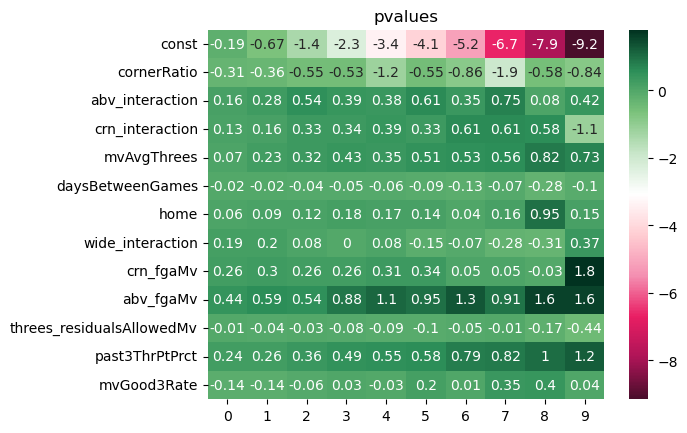

In [1683]:
plt.title('pvalues')
sns.heatmap(threes.model.params.round(2),annot=True,cmap=threes.vlog_r)

In [237]:
etl.showTables

,type,name,tbl_name,rootpage,sql
0,table,rosters,rosters,4,"CREATE TABLE rosters(\n teamId TEXT,\n s..."
1,table,players,players,2,"CREATE TABLE players(\n player_id TEXT,..."
2,table,teams,teams,6,"CREATE TABLE teams(\n team_id TEXT,\n te..."
3,table,plyrLogs,plyrLogs,123,"CREATE TABLE plyrLogs (player_id TEXT,\nteam_i..."
4,view,team_game,team_game,0,"CREATE VIEW team_game as \nSELECT season, game..."
5,table,shotsAllowed,shotsAllowed,582,"CREATE TABLE shotsAllowed (team_id TEXT,\ngame..."
6,table,preds,preds,11580,CREATE TABLE preds\n (game_...
7,view,roster_view,roster_view,0,"CREATE VIEW roster_view AS\nSELECT name, playe..."
8,table,oddsPoints,oddsPoints,761,"CREATE TABLE oddsPoints(\n name TEXT,\n ..."
9,table,oddsThrees,oddsThrees,18683,"CREATE TABLE oddsThrees(\n name TEXT,\n ..."


In [1615]:
odds.kellyCrit(-146,132)

Kelly: 0.2855
Straight Wager 35.69
Parlay 26.77


0.28553830992855384

In [428]:
start = time.time()
pd.read_sql('select * from pgames',etl.conn)
print((time.time() - start)/60)

0.1939799149831136


In [ ]:
SUM(coalesce(lc_fga,1) )OVER (PARTITION BY team_id, season ORDER by game_date) +
SUM(coalesce(rc_fga,1) )OVER (PARTITION BY team_id, season ORDER by game_date) +
SUM(coalesce(abv_fga,1) )OVER (PARTITION BY team_id, season ORDER by game_date) as teamThreesTaken,

(coalesce(lc_fgm,0) + coalesce(rc_fgm,0) + coalesce(abv_fgm,0)) / (coalesce(lc_fga,1) + coalesce(rc_fga,1) + coalesce(abv_fga,1)) thrPtPrct,
coalesce(ftm,0)/coalesce(fta,1) ftPrct,

AVG(pts) OVER (PARTITION BY player_id,season ORDER BY game_date) curPPG,
AVG(pts) OVER (PARTITION BY player_id ORDER BY game_date ROWS BETWEEN 83 PRECEDING and 1 PRECEDING) rolPPG,

 AVG(pace) OVER
    (PARTITION BY team_id,season ORDER BY game_date ROWS BETWEEN 6 PRECEDING AND 1 PRECEDING) as mvAvgTeamPace,

In [443]:
start = time.time()
pd.read_sql('select * from plyrLogs',etl.conn)
print((time.time() - start)/60)

0.04384444952011109


In [445]:
pd.read_sql('select * from plyrLogs',etl.conn).columns

Index(['player_id', 'team_id', 'game_id', 'game_date', 'min', 'ftm', 'fta',
       'reb', 'ast', 'tov', 'stl', 'blk', 'blka', 'pf', 'pfd', 'pts',
       'plus_minus', 'dd2', 'td3', 'offensiveRating', 'defensiveRating',
       'usagePercentage', 'pace', 'possessions', 'team_first', 'game_first',
       'oreb', 'oreb_contest', 'oreb_chances', 'oreb_chance_defer',
       'avg_oreb_dist', 'dreb', 'dreb_contest', 'dreb_chances',
       'dreb_chance_defer', 'avg_dreb_dist', 'ra_fgm', 'ra_fga', 'paint_fga',
       'paint_fgm', 'mid_fgm', 'mid_fga', 'lc_fgm', 'lc_fga', 'rc_fgm',
       'rc_fga', 'abv_fgm', 'abv_fga', 'Starter'],
      dtype='object')

In [703]:
data.trade_update(

Need to get 2 new players


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:06<00:00,  3.15s/it]

players has been updated with 2 rows


,PERSON_ID,DISPLAY_FIRST_LAST,HEIGHT,WEIGHT,POSITION,DRAFT_YEAR,DRAFT_NUMBER,BIRTHDATE,NBA All-Star,All-NBA1,All-NBA2,All-NBA3,All-Defensive Team1,All-Defensive Team2,NBA Most Improved Player(null),NBA Defensive Player of the Year,NBA Most Valuable Player,NBA Finals Most Valuable Player
0,1642400,Tristan Enaruna,79,220,Forward,Undrafted,Undrafted,2001-06-26,None,None,None,None,None,None,None,None,None,None
0,1643052,Chaney Johnson,79,220,Guard-Forward,Undrafted,Undrafted,2002-06-20,None,None,None,None,None,None,None,None,None,None


In [967]:
player4 = '''
'Guerschon Yabusele','Dalen Terry','Jonathan Kuminga','Buddy Hield','Kristaps Porzingis','Trayce Jackson-Davis','Tyus Jones','Balsa Koprivica'
,'Jock Landale','Lonzo Ball','Ochai Agbaji','Mason Plumlee','Ousmane Dieng','Collin Sexton','Coby White','Mike Conley','Jared McCain',
'Khris Middleton','AJ Johnson','Malaki Branham','Marvin Bagley III', 'Anthony Davis','D''Angelo Russell','Jaden Hardy','Dante Exum',
'Bennedict Mathurin','Isaiah Jackson','Ivica Zubac','Kobe Brown','Eric Gordon','Jose Alvarado','Gabe Vincent','Ayo Dosunmu','Rob Dillingham',
'Leonard Miller','Julian Phillips','Luke Kennard','Josh Minott','Hunter Thompson'
'''
player3 = ''' 'James Harden','Darius Garland','Jaden Ivey','Kevin Huerter','Dario Saric','Anfernee Simons','Nikola Vucevic',
'Walter Clayton Jr','Kyle Anderson','Georges Niang','Jaren Jackson Jr.','John Konchar','Vince Williams Jr.'

'''
player1 = '''
'Duop Reath','Vit Krejci','Dennis Schroder','Keon Ellis','Emanuel Miller','De''Andre Hunter'
'''

In [968]:
trade = pd.read_sql("SELECT name, cast(player_id as int) as player_id, cast(teamId as int) as team_id from players p left join rosters r on p.player_id = r.playerId  where name in ({}) and endDate is Null".format(player4),etl.conn)

In [969]:
from nba_api.stats.endpoints import commonallplayers

nbaRost = commonallplayers.CommonAllPlayers(is_only_current_season=1, season='2025-26').get_data_frames()[0]
f = nbaRost[['PERSON_ID','DISPLAY_FIRST_LAST','TEAM_ID','TEAM_ABBREVIATION']]
f.columns = ['player_id','name','new_team','team_abbr']

In [971]:
t = trade.merge(f,how='left',on=['player_id','name'])
t.new_team = t.new_team.astype('Int64')

In [966]:
bck1 = pd.read_sql("select * from plyrLogs where player_id in ('{}')".format("','".join(trade.player_id.values)),etl.conn)
trade['new_team'] = [1610612764,1610612752,1610612742,1610612741,1610612760,1610612762,1610612763,1610612741,1610612762,
                     1610612739,1610612738,1610612746]
trade['trade_date'] = '2026-02-03'
trade = trade.drop(['team_id'],axis=1)

TypeError: sequence item 0: expected str instance, numpy.int64 found

In [813]:
trade.merge(etl.teams,how='left',left_on='new_team',right_on='team_id')

,name,player_id,new_team,trade_date,team_id,teamAbrv
0,Anfernee Simons,1629014,1610612741,2026-02-03,1610612741,CHI
1,Kevin Huerter,1628989,1610612765,2026-02-03,1610612765,DET
2,Vince Williams Jr.,1631246,1610612762,2026-02-03,1610612762,UTA
3,Kyle Anderson,203937,1610612763,2026-02-03,1610612763,MEM
4,Jaden Ivey,1631093,1610612741,2026-02-03,1610612741,CHI
5,John Konchar,1629723,1610612762,2026-02-03,1610612762,UTA
6,Georges Niang,1627777,1610612763,2026-02-03,1610612763,MEM
7,Dario Saric,203967,1610612741,2026-02-03,1610612741,CHI
8,Jaren Jackson Jr.,1628991,1610612762,2026-02-03,1610612762,UTA
9,James Harden,201935,1610612739,2026-02-03,1610612739,CLE


In [2902]:
games = etl.get_games('2022-10-19','2025-12-15')

In [3036]:
ptGD = pd.read_sql('select distinct game_date from playerTracking',etl.conn).game_date.values

In [3037]:
remain = games[~games.GAME_DATE.isin(ptGD)].GAME_DATE.unique()

In [3040]:
etl.insert_data(temp,'playerTracking')

playerTracking has been updated with 215 rows


In [3039]:

temp = etl.get_tracking_data(['2022-10-21'])

time.sleep(np.random.random() * (np.random.random()+1))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:33<00:00, 33.82s/it]


In [3035]:
temp

,PLAYER_ID,GAME_ID,TEAM_ID,OPP_ID,GAME_DATE,DRIVE_FGM,DRIVE_FGA,DRIVE_PASSES,DRIVE_AST,DRIVE_TOV,...,CATCH_SHOOT_FG2A,CATCH_SHOOT_FG3M,CATCH_SHOOT_FG3A,PASSES_MADE,PASSES_RECEIVED,FT_AST,SECONDARY_AST,POTENTIAL_AST,AST_PTS_CREATED,AST_ADJ
0,202687,0022200013,1610612756,1610612742,2022-10-19,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1626166,0022200013,1610612756,1610612742,2022-10-19,0,2,2,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,101108,0022200013,1610612756,1610612742,2022-10-19,0,2,5,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1627814,0022200013,1610612756,1610612742,2022-10-19,1,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1629647,0022200013,1610612756,1610612742,2022-10-19,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,1630539,0022200125,1610612766,1610612763,2022-11-04,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252,1626162,0022200125,1610612766,1610612763,2022-11-04,1,4,2,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
253,1630208,0022200125,1610612766,1610612763,2022-11-04,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
254,1629023,0022200125,1610612766,1610612763,2022-11-04,0,3,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
nba_api.stats.endpoints.LeagueDashPtStats(

In [1946]:
etl.insert_data(pd.concat([set2,tracking]),'playerTracking')

playerTracking has been updated with 17,547 rows


In [1972]:
pd.read_sql('SELECT min(game_date) from playerTracking',etl.conn)

,min(game_date)
0,2024-12-16


In [ ]:
#will want this in etl as some sort of function at initialization
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
import requests

@retry(stop=stop_after_attempt(5), wait=wait_exponential(multiplier=1, min=2, max=30), 
       retry=retry_if_exception_type((requests.exceptions.Timeout, requests.exceptions.ConnectionError)))
def safe_api_call(api_func, **kwargs):
    return api_func(**kwargs).get_data_frames()[0]